In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from scipy.integrate import quad
df = pd.read_csv('supernovae.csv')

In [3]:
# define the mu function
def mu_model(z, omega_l, script_M, H_0=70,c=299792.458):
    
    integrand = lambda zp: 1.0 / np.sqrt((1 - omega_l) * (1 + zp)**3 + omega_l)
    integral_val, _ = quad(integrand, 0, z)
    
    luminosity_distance_factor = (1.0 + z) * (c / H_0) * integral_val
    
    mu = 5.0 * np.log10(luminosity_distance_factor) + 25.0 + script_M
    
    return mu

In [4]:
# defining the chi squared function
def chi_squared(params, z, mu_each, sigma):
    omega_l, m_nuisance = params
    
    mu_model_vectorized = np.vectorize(mu_model)
    mu_pred = mu_model_vectorized(z, omega_l, m_nuisance)
    return np.sum(((mu_each - mu_pred) / sigma) ** 2)

In [5]:
# algorithm to reduce chi squared
from scipy.optimize import minimize

initial_guess = [1, 1]  # [omega_l, m_nuisance]

z = df['z'].to_numpy()
mu_each = df['mu'].to_numpy()
sigma_mu = df['sigma_mu'].to_numpy()

result = minimize(
    fun=chi_squared,
    x0=initial_guess,
    args=(z, mu_each, sigma_mu),
    method='Nelder-Mead'
)

best_omega_l, best_m_nuisance = result.x
best_omega_m = 1 - best_omega_l
print(f"omega_m: = {best_omega_m}\nomega_l = {best_omega_l}\nm_nuisance = {best_m_nuisance}")

C:\Users\Enda\AppData\Local\Temp\ipykernel_10964\1365855306.py:4: RuntimeWarning: invalid value encountered in sqrt
  integrand = lambda zp: 1.0 / np.sqrt((1 - omega_l) * (1 + zp)**3 + omega_l)
C:\Users\Enda\AppData\Local\Temp\ipykernel_10964\1365855306.py:5: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral_val, _ = quad(integrand, 0, z)


omega_m: = 0.28456657613698333
omega_l = 0.7154334238630167
m_nuisance = -0.005112302142846095


In [6]:
# final chi squared value
chi_squared((best_omega_l, best_m_nuisance), df['z'], df['mu'], df['sigma_mu'])

np.float64(1035.6791611005265)

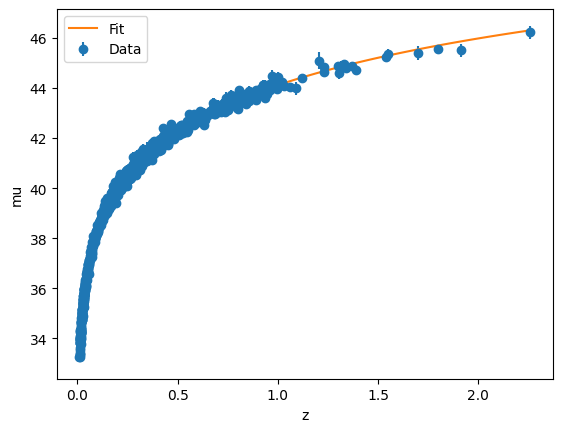

In [7]:
# plot the data and the line
plt.errorbar(df['z'], df['mu'], yerr=df['sigma_mu'], fmt='o', label='Data')
z_fit = np.linspace(df['z'].min(), df['z'].max(), 100)
mu_fit = np.vectorize(mu_model)(z_fit, best_omega_l, best_m_nuisance)
plt.plot(z_fit, mu_fit, '-', label='Fit')
plt.xlabel('z')
plt.ylabel('mu')
plt.legend()
plt.show()

# check for likelihood for a flat universe

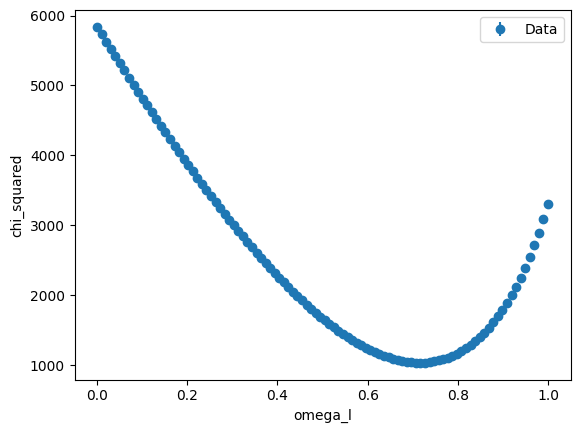

In [8]:
# first figure out chi as a result of omega_l

omega_l_values = np.linspace(0, 1, 100)
chi_values = [chi_squared((omega_l, best_m_nuisance), df['z'], df['mu'], df['sigma_mu']) for omega_l in omega_l_values]

plt.errorbar(omega_l_values, chi_values, yerr=1, fmt='o', label='Data')
plt.xlabel('omega_l')
plt.ylabel('chi_squared')
plt.legend()
plt.show()

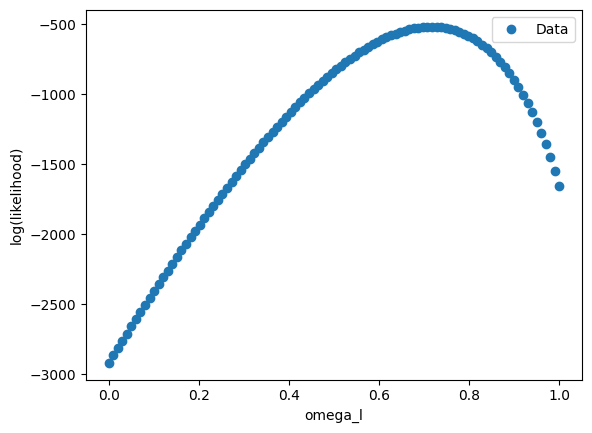

In [ ]:
# find likelihood as a result of omega_l

log_likelihood_values = -0.5 * np.array(chi_values)

plt.errorbar(omega_l_values, log_likelihood_values, fmt='o', label='Data')
plt.xlabel('omega_l')
plt.ylabel('log(likelihood)')
plt.legend()
plt.show()